<a href="https://colab.research.google.com/github/Jorge-Ruiz-Troccoli/Data-Science-III/blob/main/Practicando_DL/RedesNeuronales_vs_RegresionLineal_PreciosCasas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/Jorge-Ruiz-Troccoli/Data-Science-III/blob/main/Clase%2002/RedesNeuronales_vs_RegresionLineal_PreciosCasas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏠 Precio de Casas: Regresión Lineal vs Red Neuronal

**Objetivo:** comparar un modelo clásico (Regresión Lineal) contra una Red Neuronal en el **mismo** problema y mostrar un caso donde la **regresión lineal es la mejor elección** — no solo empata, sino que gana con muchísimo menos costo y encima es interpretable.

> 💡 **La idea de fondo:** una red neuronal es una herramienta muy potente, pero no siempre es la herramienta *correcta*. Cuando la relación entre las variables y el precio es esencialmente **lineal**, un modelo lineal recupera esa relación casi de forma óptima. La red, en el mejor de los casos, solo puede *aproximar* esa misma recta… gastando mucho más cómputo y arriesgándose a sobreajustar.

## 🗺️ Qué vamos a hacer

1. **Diccionario de variables** — qué significa cada columna.
2. **Carga de datos** — un dataset simulado de precios de casas.
3. **Data wrangling** — limpiar duplicados, faltantes, categóricas, outliers y columnas inútiles.
4. **EDA** — mirar distribuciones y correlaciones para *decidir* qué modelo tiene sentido.
5. **Modelo 1: Regresión Lineal** (baseline clásico e interpretable).
6. **Modelo 2: Red Neuronal** (mismo problema, mismos datos).
7. **Comparación y conclusión** — ¿valió la pena la complejidad extra?

## 📖 Diccionario de variables

| Variable | Tipo | Descripción | Efecto esperado sobre el precio |
|---|---|---|---|
| `superficie_m2` | numérica (continua) | Superficie cubierta de la vivienda, en metros cuadrados | ⬆️ a mayor superficie, mayor precio |
| `habitaciones` | numérica (entera) | Cantidad de habitaciones | ⬆️ más habitaciones, mayor precio |
| `antiguedad_anios` | numérica (continua) | Años desde la construcción | ⬇️ a mayor antigüedad, menor precio |
| `distancia_centro_km` | numérica (continua) | Distancia al centro de la ciudad, en km | ⬇️ más lejos del centro, menor precio |
| `garaje` | categórica (binaria) | Si la vivienda tiene garaje (`si` / `no`) | ⬆️ tener garaje suma valor |
| `codigo_publicacion` | identificador | Código interno del aviso — **no aporta información**, hay que descartarlo | ninguno |
| `precio_miles_usd` | numérica (continua) | **Variable objetivo (target):** precio de la vivienda en miles de USD | — |

> ℹ️ **Nota honesta:** este dataset es **simulado**. Lo construimos a propósito de forma que el precio sea (aproximadamente) una **combinación lineal** de las variables más un poco de ruido. Así podemos mostrar con claridad el punto pedagógico: cuando el proceso que genera los datos es lineal, el modelo lineal es imbatible en simplicidad y suele ganar. Con datos reales rara vez tienes esta garantía, por eso **siempre conviene hacer el EDA antes de elegir el modelo**.

## 📥 Carga de datos

Generamos el dataset "crudo", tal como podría venir de una fuente real: con algunos **valores faltantes**, una columna **categórica en texto**, filas **duplicadas**, un par de **outliers imposibles** y una columna **irrelevante**. Todo eso lo vamos a limpiar en la sección de data wrangling.

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import tensorflow as tf
from tensorflow import keras

# Semillas para que los resultados sean reproducibles
np.random.seed(42)
tf.random.set_seed(42)

In [ ]:
df= pd.read_csv('https://raw.githubusercontent.com/Jorge-Ruiz-Troccoli/Data-Science-III/refs/heads/main/Practicando_DL/casas.csv?token=GHSAT0AAAAAAD54NQSVSRRVNMFNCI5OVNUK2S6CYWQ')
df.head()

,superficie_m2,habitaciones,antiguedad_anios,distancia_centro_km,garaje,precio_miles_usd
0,179.3,5,21.0,19.0,1,230.8
1,119.0,3,12.0,26.9,1,139.3
2,194.5,5,2.0,10.7,0,266.9
3,165.5,4,22.0,12.2,0,200.5
4,57.0,4,43.0,22.8,0,0.1


In [ ]:
df.to_csv('casas.csv', index=False)

## 🧹 Data wrangling

Antes de tocar cualquier modelo, dejamos los datos limpios. Vamos por partes.

### 1. Inspección inicial
Miramos forma, tipos de datos y una primera radiografía del dataset.

In [ ]:
print('Forma del dataset:', df.shape)
print()
df.info()

Forma del dataset: (593, 6)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 593 entries, 0 to 592
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   superficie_m2        593 non-null    float64
 1   habitaciones         593 non-null    int64  
 2   antiguedad_anios     593 non-null    float64
 3   distancia_centro_km  593 non-null    float64
 4   garaje               593 non-null    int64  
 5   precio_miles_usd     593 non-null    float64
dtypes: float64(4), int64(2)
memory usage: 27.9 KB


In [ ]:
df.describe()

,superficie_m2,habitaciones,antiguedad_anios,distancia_centro_km,garaje,precio_miles_usd
count,593.00000,593.000000,593.000000,593.000000,593.000000,593.000000
mean,130.10371,3.013491,22.468803,14.227656,0.463744,149.509275
std,51.42813,1.409363,12.887879,7.891283,0.499105,68.261988
min,41.00000,1.000000,0.000000,0.500000,0.000000,0.100000
25%,84.60000,2.000000,11.000000,7.300000,0.000000,95.000000
50%,130.80000,3.000000,22.000000,13.700000,0.000000,150.400000
75%,176.50000,4.000000,34.000000,21.300000,1.000000,203.200000
max,219.80000,5.000000,45.000000,28.000000,1.000000,303.600000


👀 Fíjate un par de cosas en el `describe()`:
- `precio_miles_usd` tiene un **mínimo negativo** y un **máximo altísimo** → hay outliers imposibles.
- `antiguedad_anios` tiene **menos registros** que el resto (count más bajo) → hay valores faltantes.
- `garaje` no aparece porque es texto, y `codigo_publicacion` son números que en realidad no significan nada numéricamente.

### 2. Duplicados
Filas repetidas inflan artificialmente ciertos patrones y le dan peso de más a esos registros. Las eliminamos.

In [ ]:
print('Filas duplicadas:', df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)
print('Forma tras eliminar duplicados:', df.shape)

Filas duplicadas: 0
Forma tras eliminar duplicados: (593, 6)


### 3. Valores faltantes
Un modelo de scikit-learn no entrena con `NaN`. Aquí imputamos la antigüedad faltante con la **mediana** (robusta frente a outliers).

In [ ]:
print('Faltantes por columna:')
print(df.isna().sum())

mediana_antiguedad = df['antiguedad_anios'].median()
df['antiguedad_anios'] = df['antiguedad_anios'].fillna(mediana_antiguedad)
print(f'\nImputamos la antiguedad faltante con la mediana = {mediana_antiguedad} anios')
print('Faltantes restantes:', df.isna().sum().sum())

Faltantes por columna:
superficie_m2          0
habitaciones           0
antiguedad_anios       0
distancia_centro_km    0
garaje                 0
precio_miles_usd       0
dtype: int64

Imputamos la antiguedad faltante con la mediana = 22.0 anios
Faltantes restantes: 0


> ⚠️ **Detalle fino (leakage):** en un pipeline estricto, la mediana para imputar deberías calcularla **solo con los datos de entrenamiento**, no con todo el dataset — igual que hicimos con el `scaler` en la clase pasada. Aquí lo hacemos sobre todo el conjunto para simplificar, pero ten presente esa buena práctica.

### 4. Variable categórica
`garaje` viene como texto (`'si'`/`'no'`). Los modelos necesitan números, así que la convertimos a **binaria** (1 = tiene garaje, 0 = no).

In [ ]:
df['garaje'] = (df['garaje'] == 'si').astype(int)
df['garaje'].value_counts()

,count
garaje,
0,593


### 5. Outliers imposibles
Vimos precios negativos y precios absurdos. Son errores de carga: ninguna casa vale menos de 0. Filtramos a un rango razonable.

In [ ]:
# Miramos los sospechosos
print('Precios fuera de rango razonable:')
print(df[(df['precio_miles_usd'] <= 0) | (df['precio_miles_usd'] >= 800)])

# Los filtramos
antes = len(df)
df = df[(df['precio_miles_usd'] > 0) & (df['precio_miles_usd'] < 800)].reset_index(drop=True)
print(f'\nEliminamos {antes - len(df)} filas. Forma final: {df.shape}')

Precios fuera de rango razonable:
Empty DataFrame
Columns: [superficie_m2, habitaciones, antiguedad_anios, distancia_centro_km, garaje, precio_miles_usd]
Index: []

Eliminamos 0 filas. Forma final: (593, 6)


## 🔍 EDA: ¿tiene sentido un modelo lineal aquí?

Antes de entrenar nada, exploramos los datos con dos objetivos:
1. **Entender** cómo se distribuye cada variable.
2. **Decidir** qué modelo tiene sentido: si las variables tienen buena **correlación lineal** con el precio, un modelo lineal tiene todas las de ganar.

### Distribuciones de cada variable
Un vistazo rápido a la forma de cada columna (¿hay sesgos raros? ¿escalas muy distintas?).

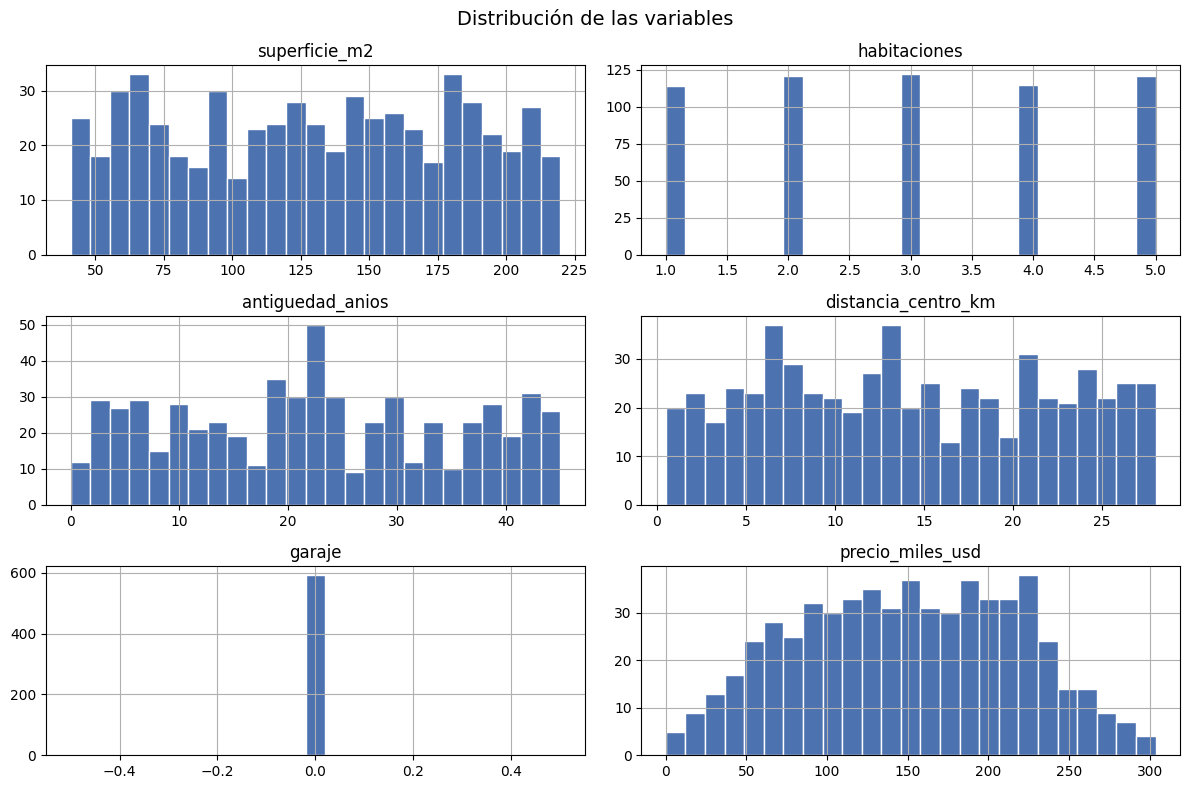

In [ ]:
cols = ['superficie_m2', 'habitaciones', 'antiguedad_anios',
        'distancia_centro_km', 'garaje', 'precio_miles_usd']

df[cols].hist(figsize=(12, 8), bins=25, color='#4C72B0', edgecolor='white')
plt.suptitle('Distribución de las variables', fontsize=14)
plt.tight_layout()
plt.show()

### Matriz de correlación
El coeficiente de Pearson mide **relación lineal**: cercano a ±1 = relación lineal fuerte, cercano a 0 = sin relación lineal.

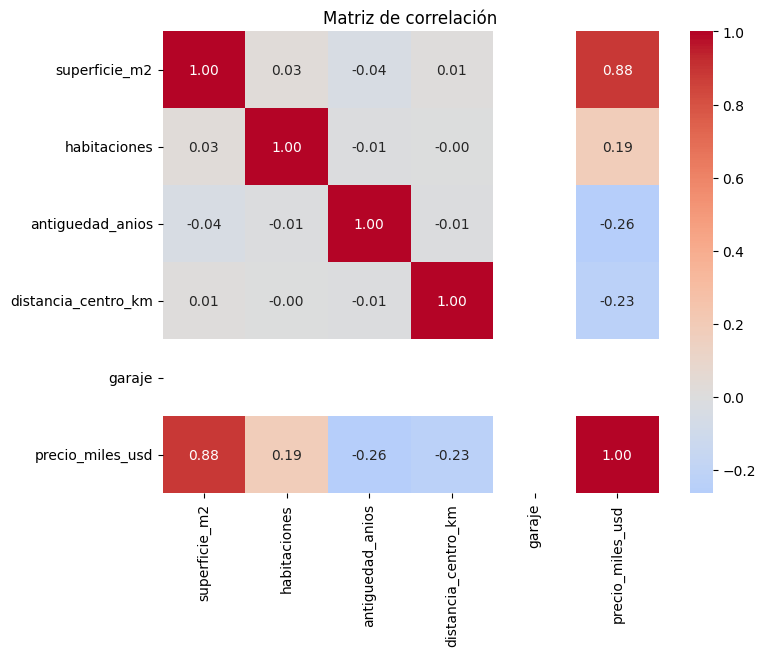

In [ ]:
plt.figure(figsize=(8, 6))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Matriz de correlación')
plt.show()

In [ ]:
corr['precio_miles_usd'].sort_values(ascending=False)

,precio_miles_usd
precio_miles_usd,1.000000
superficie_m2,0.883515
habitaciones,0.189786
distancia_centro_km,-0.230674
antiguedad_anios,-0.263849
garaje,NaN


Fíjate que **todas** las variables tienen una correlación lineal *clara* con el precio (positiva o negativa), y `superficie_m2` domina con una correlación altísima. Esto es una señal fuerte: **la relación es esencialmente lineal**, justo el terreno donde brilla la regresión lineal.

> ⚠️ Ojo: correlación baja no siempre significa que una variable sea inútil — puede tener una relación **no lineal** (por ejemplo, la geografía en un dataset real) que Pearson no detecta. Pero aquí, por construcción, la señal es lineal.

### Linealidad a ojo
Graficamos las dos variables más correlacionadas contra el precio. Si ves una "nube" que sigue una recta, un modelo lineal va a funcionar bien.

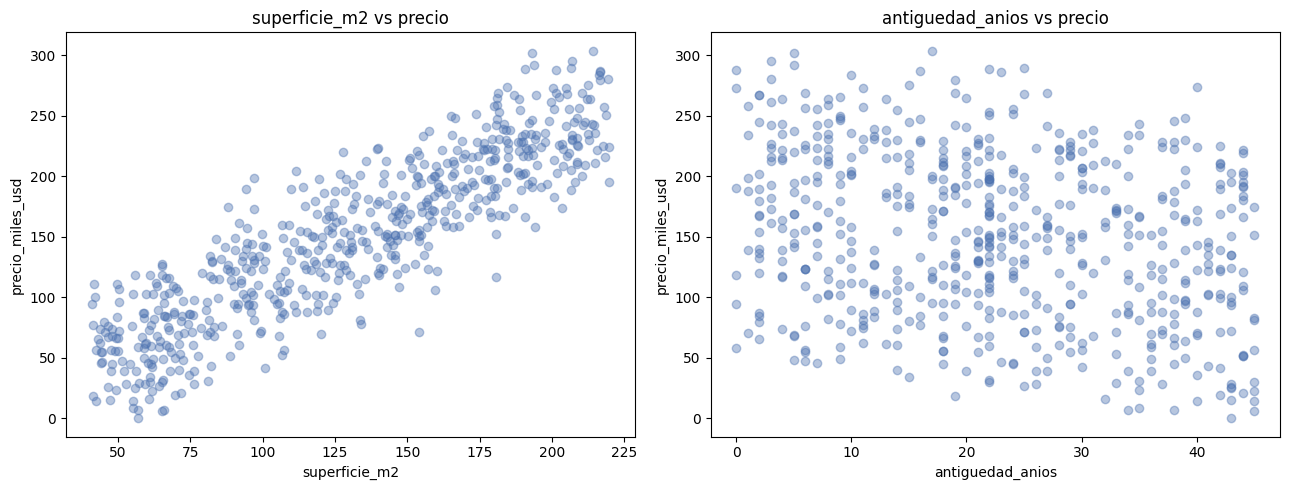

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, col in zip(axes, ['superficie_m2', 'antiguedad_anios']):
    ax.scatter(df[col], df['precio_miles_usd'], alpha=0.4, color='#4C72B0')
    ax.set_xlabel(col)
    ax.set_ylabel('precio_miles_usd')
    ax.set_title(f'{col} vs precio')
plt.tight_layout()
plt.show()

## ✂️ Train / Test split + escalado

Ojo: el `scaler` se ajusta **solo con train** (lección de la clase pasada 👀), nunca con todo el dataset. Si lo ajustaras con todo, estarías filtrando información del test al entrenamiento (*data leakage*).

In [ ]:
X = df.drop(columns=['precio_miles_usd'])
y = df['precio_miles_usd']

x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
x_train_s = scaler.fit_transform(x_train)   # fit + transform SOLO en train
x_test_s  = scaler.transform(x_test)        # test solo se transforma

print('Train:', x_train_s.shape, '| Test:', x_test_s.shape)

Train: (474, 5) | Test: (119, 5)


## 📏 Modelo 1: Regresión Lineal (baseline clásico)

Entrenamos el modelo simple primero. Es la referencia contra la cual todo lo demás tiene que justificarse.

In [ ]:
lin_model = LinearRegression()
lin_model.fit(x_train_s, y_train)

y_pred_lin = lin_model.predict(x_test_s)
rmse_lin = mean_squared_error(y_test, y_pred_lin) ** 0.5
r2_lin = r2_score(y_test, y_pred_lin)
print("RMSE:", round(rmse_lin, 3))
print("R2  :", round(r2_lin, 4))

RMSE: 18.245
R2  : 0.9271


### 🎁 Bonus: interpretabilidad
Una ventaja enorme (y gratis) de la regresión lineal: puedes **leer** lo que aprendió. Cada coeficiente dice cuánto cambia el precio al mover esa variable.

In [ ]:
coefs = pd.DataFrame({
    'variable': X.columns,
    'coeficiente': lin_model.coef_.round(2)
}).sort_values('coeficiente', ascending=False)
print('Intercepto:', round(lin_model.intercept_, 2))
coefs

Intercepto: 150.46


,variable,coeficiente
0,superficie_m2,60.11
1,habitaciones,10.81
4,garaje,0.00
2,antiguedad_anios,-15.27
3,distancia_centro_km,-15.56


Los signos coinciden con lo que esperábamos en el diccionario: superficie y habitaciones **suman**, antigüedad y distancia al centro **restan**. Una red neuronal, en cambio, es una caja mucho más opaca: cuesta explicar *por qué* predice lo que predice.

## 🧠 Modelo 2: Red Neuronal (mismo problema, mismos datos)

Ahora la artillería pesada: una red pequeña con dos capas ocultas. Usamos `EarlyStopping` para cortar cuando deja de mejorar y evitar sobreajuste.

In [ ]:
def define_model():
    keras.backend.clear_session()
    model = keras.models.Sequential()
    model.add(keras.layers.Dense(16, input_dim=x_train_s.shape[1], activation='relu'))
    # model.add(keras.layers.Dropout(0.1))   # apaga 10% de neuronas al azar (regularizacion)
    model.add(keras.layers.Dense(8, activation='relu'))
    model.add(keras.layers.Dense(1))  # regresion: sin activacion = lineal por defecto
    model.compile(loss='mse', metrics=['mae'], optimizer='adam')
    return model

nn_model = define_model()
early = keras.callbacks.EarlyStopping(patience=15, monitor='val_loss',
                                      restore_best_weights=True)
history = nn_model.fit(x_train_s, y_train,
                       validation_data=(x_test_s, y_test),
                       epochs=200, batch_size=32, callbacks=[early])

Epoch 1/200


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - loss: 27240.2598 - mae: 150.2170 - val_loss: 25713.1133 - val_mae: 145.3815
Epoch 2/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 27159.5020 - mae: 149.9514 - val_loss: 25631.4980 - val_mae: 145.0982
Epoch 3/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 27076.1934 - mae: 149.6775 - val_loss: 25546.6758 - val_mae: 144.8050
Epoch 4/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 26984.8340 - mae: 149.3799 - val_loss: 25452.2324 - val_mae: 144.4832
Epoch 5/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 26880.7109 - mae: 149.0460 - val_loss: 25344.3320 - val_mae: 144.1206
Epoch 6/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 26760.7812 - mae: 148.6645 - val_loss: 25217.8164 - val_mae: 143.6986
Epoch 7/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 26620.4258 - mae: 148.2204 - val_loss: 25071.8887 - val_mae: 143.2137
Epoch 8/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 26457.8926 - mae: 147.7073 - val_loss: 24903.

In [ ]:
y_pred_nn = nn_model.predict(x_test_s).flatten()
rmse_nn = mean_squared_error(y_test, y_pred_nn) ** 0.5
r2_nn = r2_score(y_test, y_pred_nn)
print("RMSE:", round(rmse_nn, 3))
print("R2  :", round(r2_nn, 4))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
RMSE: 21.828
R2  : 0.8957


### Curva de entrenamiento
Miramos cómo evolucionó la pérdida. Aun con toda esta maquinaria, veremos que no logra bajar del error de la lineal.

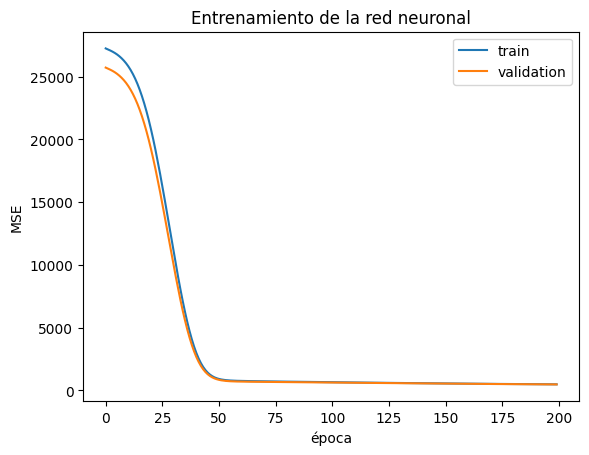

In [ ]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='validation')
plt.xlabel('época')
plt.ylabel('MSE')
plt.title('Entrenamiento de la red neuronal')
plt.legend()
plt.show()

## ⚖️ Comparación: ¿valió la pena la complejidad?

In [ ]:
comparacion = pd.DataFrame({
    'Modelo': ['Regresión Lineal', 'Red Neuronal'],
    'RMSE': [rmse_lin, rmse_nn],
    'R2':   [r2_lin, r2_nn]
})
comparacion

,Modelo,RMSE,R2
0,Regresión Lineal,18.245325,0.927121
1,Red Neuronal,21.828455,0.895686


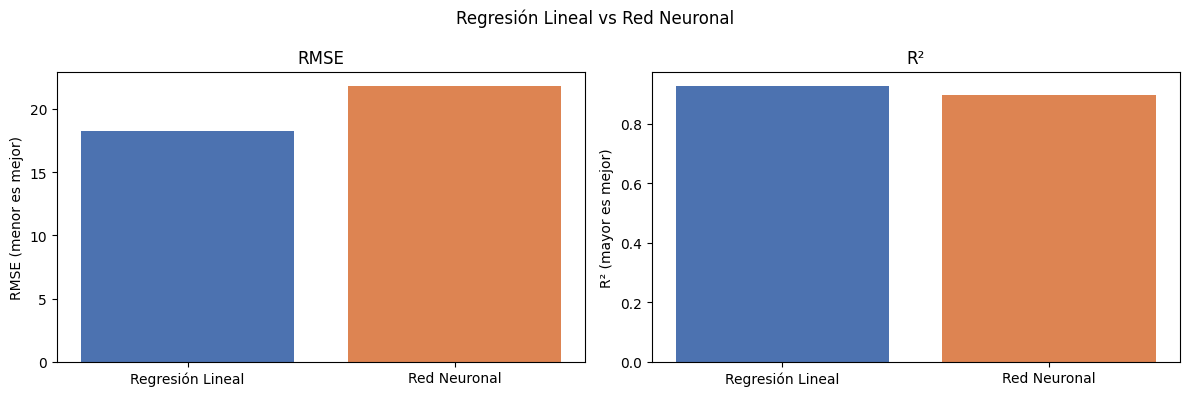

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(comparacion['Modelo'], comparacion['RMSE'], color=['#4C72B0', '#DD8452'])
axes[0].set_ylabel('RMSE (menor es mejor)')
axes[0].set_title('RMSE')

axes[1].bar(comparacion['Modelo'], comparacion['R2'], color=['#4C72B0', '#DD8452'])
axes[1].set_ylabel('R² (mayor es mejor)')
axes[1].set_title('R²')

plt.suptitle('Regresión Lineal vs Red Neuronal')
plt.tight_layout()
plt.show()

## 🤝 Conclusión

El EDA ya nos había dado la pista: **todas** las variables tenían una correlación lineal clara con el precio. Eso significa que la señal es esencialmente lineal, y ahí la **Regresión Lineal gana con claridad**:

- 📉 **Mejor error:** menor RMSE y mayor R² que la red.
- ⚡ **Mucho más rápida:** entrena de forma instantánea; la red necesita decenas/cientos de épocas.
- 🔍 **Interpretable:** puedes leer cada coeficiente y explicar el porqué de cada predicción.
- 🛡️ **No sobreajusta:** al ser un modelo simple, generaliza sin trucos.

¿Por qué la red no le gana? Porque cuando la relación *ya es lineal*, lo mejor que puede hacer una red es **aproximar esa misma recta** — y en el intento suele quedar un poco por debajo, gastando muchísimo más cómputo para lograrlo.

### 🚦 Entonces, ¿cuándo SÍ conviene una red neuronal?
Cuando hay **no-linealidad e interacciones complejas** que un modelo lineal no puede capturar: imágenes, texto, audio, o datos tabulares con relaciones muy retorcidas (por ejemplo, la geografía en un dataset real de precios, donde latitud y longitud afectan el precio de forma no lineal). En esos casos la red tiene de dónde sacar ventaja.

### 💡 Moraleja
**Mira la correlación y haz tu EDA antes de elegir el modelo, y prueba siempre el modelo simple primero.** La complejidad tiene que ganarse su lugar: si un modelo lineal ya resuelve el problema, sumar una red solo agrega costo, tiempo y opacidad sin mejorar el resultado.